<a href="https://colab.research.google.com/github/Tiyinolalekan/Deep_Learning_Image_Classifier/blob/main/Image_Classifier_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Creating a simple image classifier usingg PyTorch and CIFAR-10


In [1]:
import torch #Main PyTorch library
import torch.nn as nn # Neural network compnents
import torch.optim as optim #Optimisers for training
import torchvision #Computer-vision datasets/tools
import torchvision.transforms as transforms #Preparing images
import matplotlib.pyplot as plt #to visualise images
from torch.utils.data import DataLoader

"""
CHECKING IMPORTS AND STUFF
print(torch.__version__)
print(torch.cuda.is_available()) #Checking if a GPU is available

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') ##Resulting to use CPU if GPU isnt available. GPU is preferred cause it performs multiple AI mathematical calculations faster
print(device)

"""

"\nCHECKING IMPORTS AND STUFF\nprint(torch.__version__)\nprint(torch.cuda.is_available()) #Checking if a GPU is available\n\ndevice = torch.device('cuda' if torch.cuda.is_available() else 'cpu') ##Resulting to use CPU if GPU isnt available. GPU is preferred cause it performs multiple AI mathematical calculations faster\nprint(device)\n\n"

In [2]:
transform = transforms.ToTensor() #Converting images to an operable format called Tensors which resembles an array of numbers

#Creating Training data set using torchvision library
train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

#Creating Test data set using torchvision library
test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)



100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


In [3]:
#CIFAR-10 Known classes/categories
classes = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
)

#Peeking at one image in our dataset
image, label = train_dataset[0]
print(image.shape) #First element represents the number of color channels,a nd remaning two is the height and width based on the number of pixels
print(label)
print(classes[label])

torch.Size([3, 32, 32])
6
frog


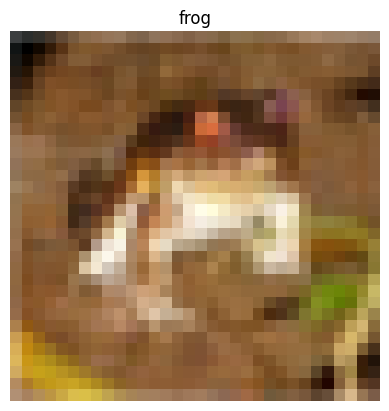

In [4]:
#Displaying image using matplotlib

plt.imshow(image.permute(1,2,0)) #rearranged dimensions to be height, width and channels where, 0,1,2 are indicies from the image.shape array e.g., [3,32,32] becomes (32,32,3)
plt.title(classes[label])
plt.axis("off")
plt.show()


**CREATING** **THE** **MODEL**

In [5]:
import torch
import torch.nn as nn

# Define device since it was commented out in the first cell
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class CNN(nn.Module): #Inheritance class
  def __init__(self):
    super().__init__() ##Inheriting attributes from parent class

    #First convolutional layer
    self.conv1 = nn.Conv2d(
        in_channels=3, #Cause its an RGB
        out_channels=16,  #We're gonna learn 16 diff filters where one filter detects stuff like edges/vertical edges/corners etc
        kernel_size=3, # region of image we're looking at at a time
        padding=1
    )

    self.pool = nn.MaxPool2d(
        kernel_size=2,
        stride=2
    )

    #Second convolutional layer
    self.conv2 = nn.Conv2d(
        in_channels=16,
        out_channels=32,
        kernel_size=3,
        padding=1
    )
    #Fully connected layer to 128 features
    self.fc1 = nn.Linear(
       32*8*8,
       128
    )
    #Fully connected layer to 10 features
    self.fc2 = nn.Linear(
       128,
       10
    )

  def forward(self, x):
    #First convolution then rectified linear unit then max pooling
    x = self.conv1(x)
    x = torch.relu(x)
    x = self.pool(x)

    #Second convolution and others
    x = self.conv2(x)
    x = torch.relu(x)
    x = self.pool(x)

    x = torch.flatten(x, 1) #Converting second layer of 32 x 8 x 8 to 2048
    x = torch.relu(self.fc1(x))
    x = self.fc2(x)
    return x

# Instantiate and move to device (correctly indented outside the class)
model = CNN()
model = model.to(device) #Moving model to GPU if available
print(model)

CNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


Passing an image through to test the function - result is gonna be bad as the model isnt trained yet.


In [6]:
image, label = train_dataset[0]

image = image.unsqueeze(0)
image = image.to(device)

output = model(image)

print(output)
print(output.shape)

tensor([[-0.0011,  0.0201, -0.0191,  0.0061,  0.0691, -0.0423,  0.0406, -0.1271,
          0.0161, -0.0657]], grad_fn=<AddmmBackward0>)
torch.Size([1, 10])


TRAINING THE MODEL

In [7]:
#Create Dataloaders
#The model receives 64 images at once, makes 64 predictions, calculates their combined loss, and then updates its weights.

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

#Loss Function
criterion = nn.CrossEntropyLoss()

#Optimizer
optimizer = optim.Adam( #the algorithm we're using to update the weights
    model.parameters(),#all the weights and biases the model can learn
    lr=0.001 #learning rate, controlling how big each weight update is
)


Training Loop

In [14]:
num_epochs = 10 #the model goes through the entire 50,000-image training dataset 10 times.
train_losses = []

for epoch in range(num_epochs) :

  model.train() #Training the model
  running_loss = 0.0

  for images, labels in train_loader: #Iterating through the 64/50,000-image training dataset

    images = images.to(device) #moving images to GPU if available
    lables = labels.to(device)

    optimizer.zero_grad() #clears the gradients from the previous batch

    outputs = model(images) #forward pass; the CNN makes predictions.

    #outputs are raw logits; CrossEntropyLoss handles softmax internally

    loss = criterion(outputs, labels) # calculates how wrong those predictions are.

    loss.backward() #backpropagation; calculates the gradient for EVERY learnable weight.

    optimizer.step() #uses those gradients to update the weights.

    running_loss += loss.item()

  epoch_loss = running_loss/len(train_loader)
  train_losses.append(epoch_loss)
  print(
        f"Epoch {epoch+1}/{num_epochs},"
        f"Loss: {epoch_loss:.4f}"
    )

Epoch 1/10,Loss: 0.6767
Epoch 2/10,Loss: 0.6470
Epoch 3/10,Loss: 0.6227
Epoch 4/10,Loss: 0.5952
Epoch 5/10,Loss: 0.5695
Epoch 6/10,Loss: 0.5492
Epoch 7/10,Loss: 0.5285
Epoch 8/10,Loss: 0.5016
Epoch 9/10,Loss: 0.4843
Epoch 10/10,Loss: 0.4571


**Testing**
___________
**How to read the result:**


*   10% would be random guessing, since there are 10 classes.
*   Mid-60s to low-70s is what I'd expect for this small two-conv-layer CNN.
*   Your final training loss of 0.7125 is the other number to keep. A big gap between how well it does on training data and on test data is the sign of overfitting, which we'll get to.








In [16]:
model.eval() #Evaluation mode

correct = 0
total = 0

with torch.no_grad(): #no gradients needed cause we're learning not measuring

#each loop iteration hands the model 64 test images together instead of one at a time (the 10,000 test images are processed in about 157 batches).
#The last batch is just smaller, since 10,000 doesn't divide evenly by 64.
  for images, labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images) #logits for each test image So outputs has shape [64, 10]: 64 rows (one per image) and 10 columns (one score per class).

    _, predicted = torch.max(outputs,1) #class with the highest logit

    total += labels.size(0) #images in this batch
    correct += (predicted == labels).sum().item() #how many were right

accuracy = 100 * correct/total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 68.43%


**TRAINING ACCURACY FOR COMPARISON**

In [15]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

train_accuracy = 100 * correct / total

print(f"Train accuracy: {train_accuracy:.2f}%")

Train accuracy: 86.49%


***BASELINE UPON FIRST-EVER RUN***



*   Final Training Loss: ***0.7125***
*   Test Accuracy: ***68.42%***
*   Train Accuracy: ***86.49%***
*   Gap: approximately 18 points.

Model if overfitting as its memorised quirks specific to the training data rather than learning actual patterns. This is normal for the baseline but should be improved in futur runs.





***LOSS CURVE***

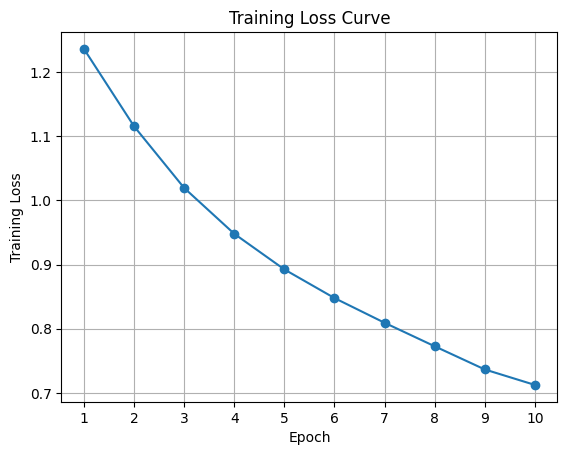

In [19]:

plt.plot(range(1, len(train_losses) + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss Curve')
plt.xticks(range(1, len(train_losses) + 1))
plt.grid(True)
plt.show()

***ERROR ANALYSIS***

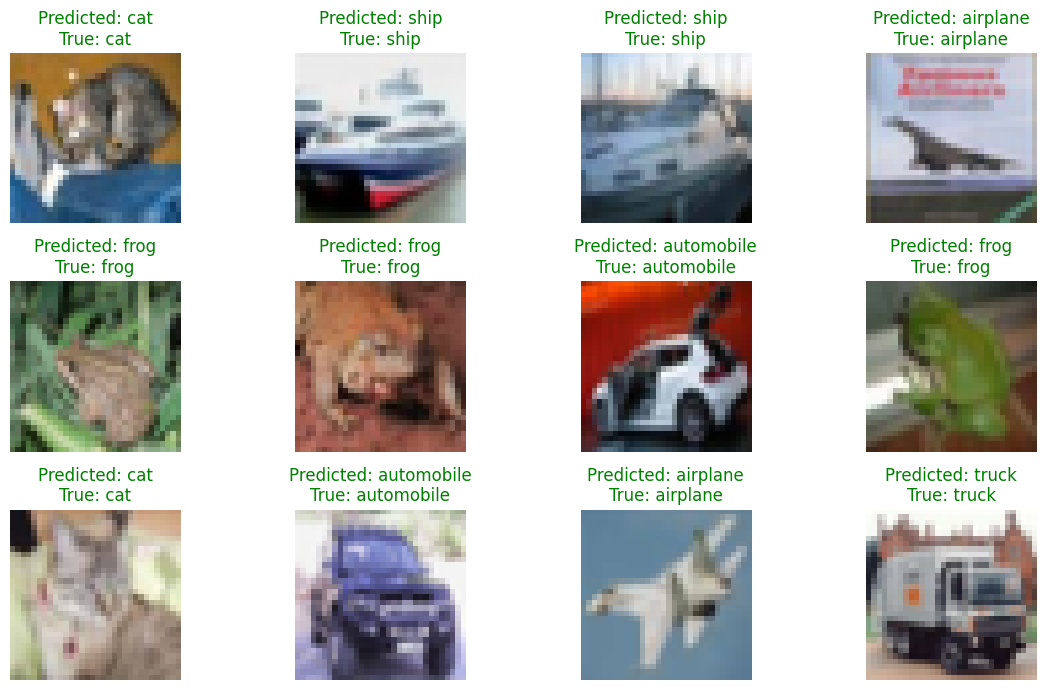

In [22]:
model.eval()

images, labels = next(iter(test_loader)) #first 64 test images batch

with torch.no_grad():
  outputs = model(images.to(device))
  _,predicted = torch.max(outputs,1)

predicted = predicted.to('cpu') #back to the cpu for plotting if GPU was available
plt.figure(figsize=(12,7))

for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(images[i].permute(1,2,0))
  colour = 'green' if predicted[i] == labels[i] else 'red'
  plt.title(
      f"Predicted: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}",
      color = colour
  )
  plt.axis("off")

plt.tight_layout()
plt.show()



Wrong in this batch: 14 out of 64


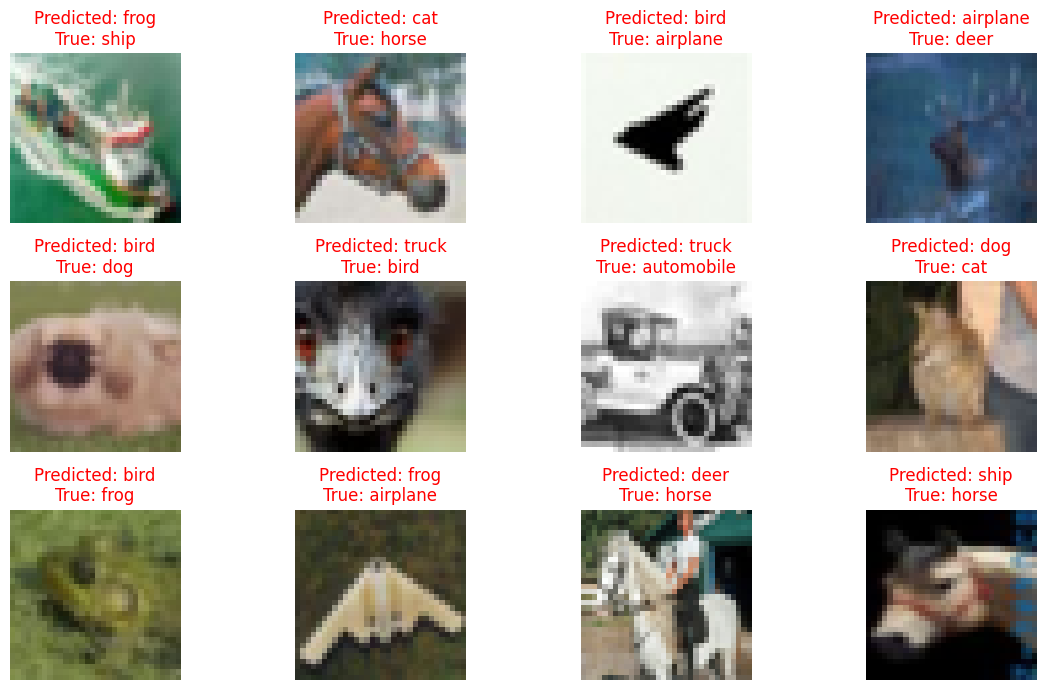

In [21]:
wrong = (predicted != labels).nonzero().flatten()

print(f"Wrong in this batch: {len(wrong)} out of {len(labels)}")

plt.figure(figsize=(12,7))

for n, i in enumerate(wrong[:12]):
  plt.subplot(3,4,n+1)
  plt.imshow(images[i].permute(1,2,0))
  plt.title(
      f"Predicted: {classes[predicted[i]]}\nTrue: {classes[labels[i]]}",
      color = 'red'
  )
  plt.axis("off")

plt.tight_layout()
plt.show()